# Cx Analytics

In [4]:
# Importing Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load dataset
df = pd.read_excel("../Call_Volume_Trend_Analysis.xlsx")

In [6]:
# Convert date and time columns
df['Date_&_Time'] = pd.to_datetime(df['Date_&_Time'], format='%d-%m-%Y')
df['Time'] = pd.to_numeric(df['Time'], errors='coerce')

In [7]:
# Convert Duration to seconds
df['Call_Seconds (s)'] = pd.to_numeric(df['Call_Seconds (s)'], errors='coerce')

### 1️⃣ Average Call Duration Per Time Bucket

C:\Users\mohak\AppData\Local\Temp\ipykernel_17572\734029163.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_duration.index, y=avg_duration.values, palette="Blues_r")


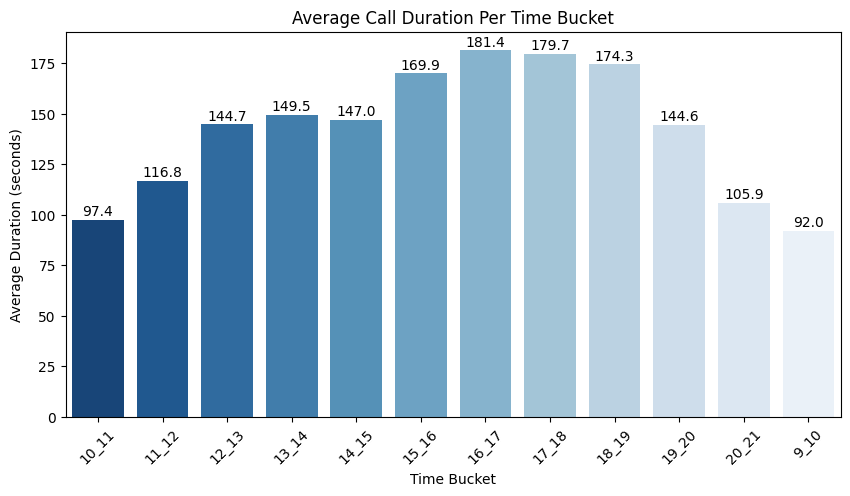

In [8]:
# Calculate average call duration per time bucket
avg_duration = df.groupby('Time_Bucket')['Call_Seconds (s)'].mean()

# Plot the bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=avg_duration.index, y=avg_duration.values, palette="Blues_r")

# Add data labels
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2,  # X position
            p.get_height() + 2,  # Y position (a little above the bar)
            f'{p.get_height():.1f}',  # Label text (formatted to 1 decimal)
            ha='center',  # Horizontal alignment
            fontsize=10,  # Font size
            color='black')  # Label color

# Customize labels and title
plt.xticks(rotation=45)
plt.xlabel("Time Bucket")
plt.ylabel("Average Duration (seconds)")
plt.title("Average Call Duration Per Time Bucket")
plt.show()

### 2️⃣ Call Volume Analysis

C:\Users\mohak\AppData\Local\Temp\ipykernel_17572\139110090.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=call_volume.index, y=call_volume.values, palette="Greens_r")


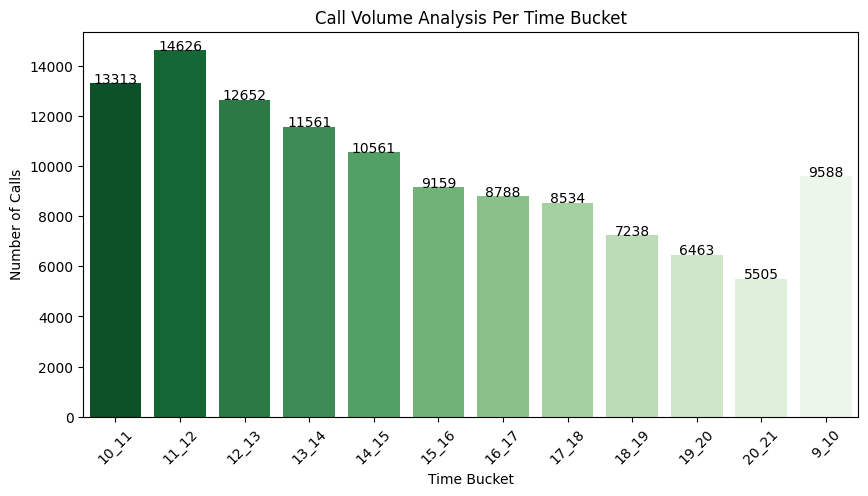

In [9]:
# Calculate call volume per time bucket
call_volume = df.groupby('Time_Bucket').size()

# Plot the bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=call_volume.index, y=call_volume.values, palette="Greens_r")

# Add data labels
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2,  # X position (center of the bar)
            p.get_height() + 2,  # Y position (slightly above the bar)
            f'{int(p.get_height())}',  # Label text (integer format)
            ha='center',  # Horizontal alignment
            fontsize=10,  # Font size
            color='black')  # Label color

# Customize labels and title
plt.xticks(rotation=45)
plt.xlabel("Time Bucket")
plt.ylabel("Number of Calls")
plt.title("Call Volume Analysis Per Time Bucket")
plt.show()

### 3️⃣ Manpower Planning

In [ ]:
# Assumptions
abandon_rate_current = 0.30  # 30%
abandon_rate_target = 0.10   # 10%
agent_call_hours = 7.5 * 0.6 # 60% of 7.5 hours (4.5 hours per day)

# Calculate required agents per time bucket
answered_calls = call_volume * (1 - abandon_rate_target)
avg_handle_time = avg_duration.mean() / 3600  # Convert to hours
agents_required = (answered_calls * avg_handle_time) / agent_call_hours

# Display manpower allocation
manpower_df = pd.DataFrame({
    "Time_Bucket": call_volume.index,
    "Agents_Required": agents_required
    })
print(manpower_df)

            Time_Bucket  Agents_Required
Time_Bucket                             
10_11             10_11       104.985975
11_12             11_12       115.340259
12_13             12_13        99.773346
13_14             13_14        91.169748
14_15             14_15        83.283774
15_16             15_16        72.227638
16_17             16_17        69.301942
17_18             17_18        67.298904
18_19             18_19        57.078682
19_20             19_20        50.967051
20_21             20_21        43.412288
9_10               9_10        75.610721


### 4️⃣ Night Shift Manpower Planning

In [ ]:
night_call_multiplier = 0.3  # 30 calls for every 100 day calls
night_calls = call_volume * night_call_multiplier
answered_night_calls = night_calls * (1 - abandon_rate_target)
agents_required_night = (answered_night_calls * avg_handle_time) / agent_call_hours

# Display night shift manpower allocation
night_manpower_df = pd.DataFrame({
    "Time_Bucket": call_volume.index, 
    "Night_Agents_Required": agents_required_night
    })
print(night_manpower_df)

            Time_Bucket  Night_Agents_Required
Time_Bucket                                   
10_11             10_11              31.495792
11_12             11_12              34.602078
12_13             12_13              29.932004
13_14             13_14              27.350924
14_15             14_15              24.985132
15_16             15_16              21.668291
16_17             16_17              20.790582
17_18             17_18              20.189671
18_19             18_19              17.123604
19_20             19_20              15.290115
20_21             20_21              13.023686
9_10               9_10              22.683216
